## how does real GPT2 look like?

In [ ]:
from transformers import GPT2LMHeadModel

/home/mzums/miniconda3/envs/fakewiki/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")  # 124M
sd_hf = model_hf.state_dict()

# tensors
for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5402.82it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

^ *GPT2 has 50257 tokens*  
768 dimentional embedding  
1024 max sequence length

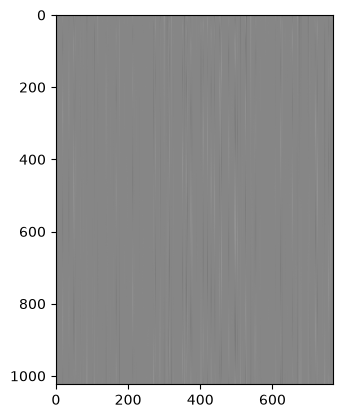

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

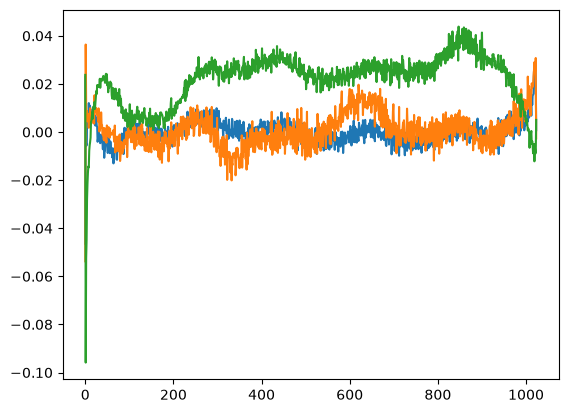

In [ ]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

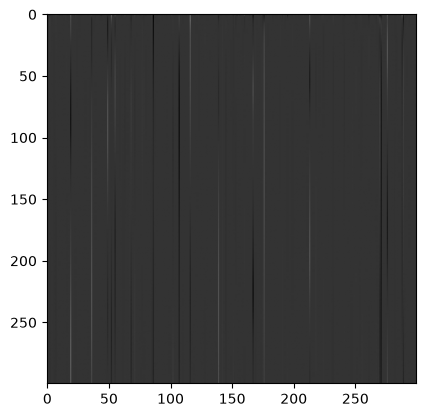

In [ ]:
plt.imshow(sd_hf["transformer.wpe.weight"][:300,:300], cmap="gray")

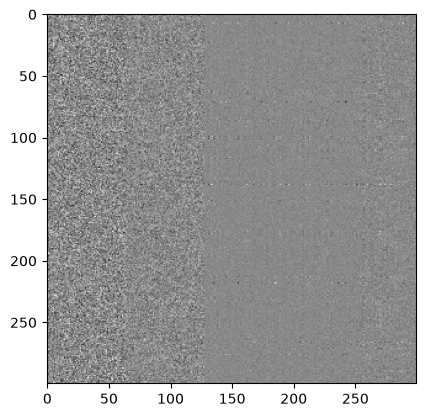

In [ ]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300], cmap="gray")

### sampling

In [ ]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model", max_length=30, num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10928.63it/s]


[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_

[{'generated_text': 'Hello, I\'m a language model for you" —Miles Teller (@milesteller) October 13, 2015\n\nI guess I\'ll just have to watch out for this.\n\nUPDATE: This post has been updated with comments from the author.'},
 {'generated_text': "Hello, I'm a language model. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the world. I'm a model of the wo

In [ ]:
generator("Machine learning (ML) is a field of study in artificial intelligence ", max_length=30, num_return_sequences=5) 

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Machine learning (ML) is a field of study in artificial intelligence \xa0for which there are many groups working on the same problem. ML is a natural language learning algorithm that is relatively straightforward to use. ML is also the study of problems that are difficult to solve with finite-dimensional ML algorithms. ML algorithms can be thought of as a kind of learning machine, but they are very different from machine learning. ML is an algorithm that has an easy description of its data (that is, it is only partially able to read and understand some data, and that is not the same as the machine learning problem or problem solving problem that the machine learning problem solves). It is a type of machine learning algorithm that has the following characteristics: It can learn to solve most problems by one step (for example, if one character in the data is in the wrong place, then it will not be able to read the correct character).\nIt can learn to solve most probl

### training

In [ ]:
with open('wiki_clean.txt', 'r', encoding='utf-8') as f:
    text = f.read()

data = text[:1000]
print(data[:100])

<SOA>
TITLE: Lego Star Wars (disambiguation)

ABSTRACT:
Lego Star Wars is a Lego theme based around 


In [ ]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[27, 15821, 32, 29, 198, 49560, 2538, 25, 33198, 2907, 6176, 357, 6381, 4131, 328, 2288, 8, 198, 198, 6242, 18601, 10659, 25, 198]


we want tokens to be the shape of ids, which is (B, T)

In [ ]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[   27, 15821,    32,    29,   198, 49560],
        [ 2538,    25, 33198,  2907,  6176,   357],
        [ 6381,  4131,   328,  2288,     8,   198],
        [  198,  6242, 18601, 10659,    25,   198]])
tensor([[15821,    32,    29,   198, 49560,  2538],
        [   25, 33198,  2907,  6176,   357,  6381],
        [ 4131,   328,  2288,     8,   198,   198],
        [ 6242, 18601, 10659,    25,   198, 11484]])


-------------

### using my tokenizer

In [ ]:
def load_merges(filepath):
    merges = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f, start=256):
            # Pomijamy puste linie
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 2:
                continue  # niepoprawny format, pomijamy
            a, b = int(parts[0]), int(parts[1])
            merges[(a, b)] = idx
    return merges

In [ ]:
vocab_size = 5000
num_merges = vocab_size - 256

In [ ]:
merges = load_merges('my_merges.bpe')

vocab = [bytes([i]) for i in range(256)]
vocab.extend([b''] * (vocab_size - 256))

for i in range(256):
    vocab[i] = bytes([i])

for pair, idx in sorted(merges.items(), key=lambda item: item[1]):
    vocab[idx] = vocab[pair[0]] + vocab[pair[1]]

In [ ]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids, pair, idx):
    newids = []
    i = 0
    while i < len(ids):
        if i < len(ids)-1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids

In [ ]:
def encode(text):
    tokens = list(text.encode("utf-8"))
    tokens.append(0)
    while len(tokens) >= 2:
        stats = get_stats(tokens)
        pair = min(stats, key=lambda p:merges.get(p, float('inf')))
        if pair not in merges:
            break
        idx = merges[pair]
        tokens = merge(tokens, pair, idx)
    return tokens

In [ ]:
def decode(ids):
    tokens = b"".join(vocab[idx] for idx in ids)
    # delete all the 0 bytes
    tokens = tokens.replace(b'\x00', b'')
    text = tokens.decode("utf-8", errors="replace")
    return text

In [ ]:
# create vocab
vocab = [bytes([i]) for i in range(256)]
vocab.extend([b''] * (vocab_size - 256))

for i in range(256):
    vocab[i] = bytes([i])

for pair, idx in sorted(merges.items(), key=lambda item: item[1]):
    vocab[idx] = vocab[pair[0]] + vocab[pair[1]]

SOA_ID = len(vocab)
EOA_ID = len(vocab) + 1
vocab.extend([b"<SOA>", b"<EOA>"])

In [ ]:
import regex as re
article_pat = re.compile(r"<SOA>(.*?)<EOA>", re.DOTALL)
articles = re.findall(article_pat, text)
articles[0]

'\nTITLE: Lego Star Wars (disambiguation)\n\nABSTRACT:\nLego Star Wars is a Lego theme based around models of vehicles and sets from the Star Wars franchise. It can also refer to:\n  - Lego Star Wars: The Video Game, a video game that provides a humorous and child-oriented retelling of the Star Wars prequel trilogy\n    - Lego Star Wars II: The Original Trilogy, the sequel to Lego Star Wars: The Video Game that retells the original trilogy\n    - Lego Star Wars: The Complete Saga, a compilation of the first two games\n    - Lego Star Wars III: The Clone Wars, the third in the series of games\n    - Lego Star Wars: The Force Awakens\n    - Lego Star Wars: The Skywalker Saga, an updated version following the story of all 9 feature films\n  - Several animated shorts and specials airing on Cartoon Network\n    - Lego Star Wars: Revenge of the Brick, a 2005 mini-movie based on Revenge of the Sith\n    - Lego Star Wars: The Quest for R2-D2, a 2009 animated mini-movie and online game based lo

In [ ]:
gpt2pat = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""")


In [ ]:
all_tokenized_articles = []

for article in articles:
    fragments = gpt2pat.findall(article)
    tokenized_article = []
    
    for fragment in fragments:
        tokenized_fragment = encode(fragment)
        tokenized_article.extend(tokenized_fragment)
    
    final_article_tokens = [SOA_ID] + tokenized_article + [EOA_ID]
    all_tokenized_articles.append(final_article_tokens)

all_tokens = []
for article_tokens in all_tokenized_articles:
    all_tokens.extend(article_tokens)

In [ ]:
all_tokens[:10]

[5000, 274, 520, 366, 4258, 2696, 3128, 367, 4086, 1600]

In [ ]:
decode(all_tokens)

'<SOA>\nTITLE: Lego Star Wars (disambiguation)\n\nABSTRACT:\nLego Star Wars is a Lego theme based around models of vehicles and sets from the Star Wars franchise. It can also refer to:\n  - Lego Star Wars: The Video Game, a video game that provides a humorous and child-oriented retelling of the Star Wars prequel trilogy\n    - Lego Star Wars II: The Original Trilogy, the sequel to Lego Star Wars: The Video Game that retells the original trilogy\n    - Lego Star Wars: The Complete Saga, a compilation of the first two games\n    - Lego Star Wars III: The Clone Wars, the third in the series of games\n    - Lego Star Wars: The Force Awakens\n    - Lego Star Wars: The Skywalker Saga, an updated version following the story of all 9 feature films\n  - Several animated shorts and specials airing on Cartoon Network\n    - Lego Star Wars: Revenge of the Brick, a 2005 mini-movie based on Revenge of the Sith\n    - Lego Star Wars: The Quest for R2-D2, a 2009 animated mini-movie and online game bas

In [ ]:
tokens = all_tokens
print(tokens[:24])

[5000, 274, 520, 366, 4258, 2696, 3128, 367, 4086, 1600, 404, 3214, 423, 274, 274, 526, 366, 274, 76, 530, 284, 2696, 3128, 331]


In [ ]:
print(decode(tokens)[:24])

<SOA>
TITLE: Lego Star W


In [ ]:
import numpy as np

# flatten
flat_tokens = np.array(all_tokens, dtype=np.int32)  # (total_length,)
lengths = np.array([len(art) for art in all_tokenized_articles], dtype=np.int32)

# saving tokens
np.save('tokens_flat.npy', flat_tokens)
np.save('tokens_lengths.npy', lengths)

In [ ]:
# getting vocab from files
flat_tokens = np.load('../dev/tokens_flat.npy')   # (total_length,)
lengths = np.load('../dev/tokens_lengths.npy')    # (liczba_artykułów,)

# get tokens for every article
all_tokens = []
start = 0
for length in lengths:
    all_tokens.append(flat_tokens[start:start+length].tolist())
    start += length

# get article
tokens_list = all_tokens[0]

# get starting tensor
tokens = torch.tensor(tokens_list, dtype=torch.long)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)   # (num_return_sequences, seq_len)
x = tokens.to('cuda')


def decode(ids):
    tokens = b"".join(vocab[idx] for idx in ids)
    # delete all the 0 bytes
    tokens = tokens.replace(b'\x00', b'')
    text = tokens.decode("utf-8", errors="replace")
    return text


with open('../dev/vocab.json', 'r', encoding='utf-8') as f:
    vocab_as_strings = json.load(f)

vocab = [token.encode('utf-8') for token in vocab_as_strings]

In [ ]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[5000,  274,  520,  366, 4258, 2696],
        [3128,  367, 4086, 1600,  404, 3214],
        [ 423,  274,  274,  526,  366,  274],
        [  76,  530,  284, 2696, 3128,  331]])
tensor([[ 274,  520,  366, 4258, 2696, 3128],
        [ 367, 4086, 1600,  404, 3214,  423],
        [ 274,  274,  526,  366,  274,   76],
        [ 530,  284, 2696, 3128,  331,  306]])


In [ ]:
import json

vocab_as_strings = [token.decode('utf-8', errors='replace') for token in vocab]

with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_as_strings, f, ensure_ascii=False, indent=2)